<a href="https://colab.research.google.com/github/paavan1275/Predictive-Analytics/blob/Credit-Card-Fraud-Detection/Ipl-Match-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
data=pd.read_csv('IPL IMB381IPL2013.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

In [ ]:
data.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,0,0.0,0,0,0,0.00,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,185,37.6,0,0,0,0.00,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,288,32.9,0,167,39,18.56,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,51,36.8,0,58,11,5.80,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,0,0.0,0,1317,71,32.93,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000


In [ ]:
Y=data['SOLD PRICE']
data=data.drop(columns=['Sl.NO.',	'PLAYER NAME','TEAM','AUCTION YEAR','BASE PRICE','SOLD PRICE'])

In [ ]:
data.head()

,AGE,COUNTRY,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL
0,2,SA,Allrounder,0,0,0,0.00,0,0.0,0,0,0,0.00,0.00,0,307,15,20.47,8.90,13.93
1,2,BAN,Bowler,214,18,657,71.41,185,37.6,0,0,0,0.00,0.00,0,29,0,0.00,14.50,0.00
2,2,IND,Bowler,571,58,1269,80.62,288,32.9,0,167,39,18.56,121.01,5,1059,29,36.52,8.81,24.90
3,1,IND,Bowler,284,31,241,84.56,51,36.8,0,58,11,5.80,76.32,0,1125,49,22.96,6.23,22.14
4,2,IND,Batsman,63,0,79,45.93,0,0.0,0,1317,71,32.93,120.71,28,0,0,0.00,0.00,0.00


In [ ]:
categorical=['AGE','COUNTRY','PLAYING ROLE','CAPTAINCY EXP']

In [ ]:
data_en=pd.get_dummies(data,columns=categorical,drop_first=True).astype(float)

In [ ]:
data_en

,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AGE_2,AGE_3,COUNTRY_BAN,COUNTRY_ENG,COUNTRY_IND,COUNTRY_NZ,COUNTRY_PAK,COUNTRY_SA,COUNTRY_SL,COUNTRY_WI,COUNTRY_ZIM,PLAYING ROLE_Batsman,PLAYING ROLE_Bowler,PLAYING ROLE_W. Keeper,CAPTAINCY EXP_1
0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,307.0,15.0,20.47,8.90,13.93,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,214.0,18.0,657.0,71.41,185.0,37.6,0.0,0.0,0.00,0.00,0.0,29.0,0.0,0.00,14.50,0.00,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,571.0,58.0,1269.0,80.62,288.0,32.9,167.0,39.0,18.56,121.01,5.0,1059.0,29.0,36.52,8.81,24.90,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,284.0,31.0,241.0,84.56,51.0,36.8,58.0,11.0,5.80,76.32,0.0,1125.0,49.0,22.96,6.23,22.14,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,63.0,0.0,79.0,45.93,0.0,0.0,1317.0,71.0,32.93,120.71,28.0,0.0,0.0,0.00,0.00,0.00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.0,0.0,0.0,0.00,0.0,0.0,49.0,16.0,9.80,125.64,2.0,0.0,0.0,0.00,0.00,0.00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
126,6398.0,7.0,6814.0,75.78,3.0,86.6,3.0,3.0,3.00,42.85,0.0,0.0,0.0,0.00,0.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
127,1775.0,9.0,8051.0,87.58,109.0,44.3,1237.0,66.0,26.32,131.88,67.0,569.0,23.0,24.74,7.02,21.13,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
128,1114.0,288.0,790.0,73.55,278.0,35.4,99.0,23.0,9.90,91.67,1.0,1783.0,65.0,27.43,7.75,21.26,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X=data_en
X=sm.add_constant(X)

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
model=sm.OLS(Y_train,X_train).fit()

In [ ]:
pred=model.predict(X_test)
r2_score(pred,Y_test)

0.02894515106363349

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             SOLD PRICE   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     2.883
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           0.000114
Time:                        13:39:57   Log-Likelihood:                -1450.6
No. Observations:                 104   AIC:                             2965.
Df Residuals:                      72   BIC:                             3050.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   3.758e+05   2.29e+05      1.642      0.105   -8.04e+04    8.32e+05
T-RUNS                   -53.7890     32.717     -1.644      0.105    -119.010      11.432
T-WKTS                  -132.5967    609.753     -0.217      0.828   -1348.116    1082.923
ODI-RUNS-S                57.9600     31.507      1.840      0.070      -4.848     120.768
ODI-SR-B                -524.1450   1576.637     -0.332      0.741   -3667.113    2618.823
ODI-WKTS                 815.3944    832.388      0.980      0.331    -843.941    2474.730
ODI-SR-BL               -773.3092   1536.333     -0.503      0.616   -3835.934    2289.315
RUNS-S                   114.7205    173.309      0.662      0.510    -230.764     460.205
HS                     -5516.3354   2586.328     -2.133      0.036   -1.07e+04    -360.585
AVE                     2.156e+04   7774.242      2.773      0.007    6062.608    3.71e+04
SR-B                   -1324.7218   1373.130     -0.965      0.338   -4062.007    1412.564
SIXERS                  4264.1001   4089.600      1.043      0.301   -3888.368    1.24e+04
RUNS-C                    69.8250    297.670      0.235      0.815    -523.569     663.219
WKTS                    3075.2422   7262.445      0.423      0.673   -1.14e+04    1.76e+04
AVE-BL                  5182.9335   1.02e+04      0.507      0.614   -1.52e+04    2.56e+04
ECON                   -6820.7781   1.31e+04     -0.520      0.604    -3.3e+04    1.93e+04
SR-BL                  -7658.8094    1.4e+04     -0.545      0.587   -3.57e+04    2.03e+04
AGE_2                  -2.308e+05   1.14e+05     -2.022      0.047   -4.58e+05   -3279.165
AGE_3                  -2.168e+05   1.52e+05     -1.424      0.159    -5.2e+05    8.67e+04
COUNTRY_BAN            -1.221e+05   4.39e+05     -0.278      0.782   -9.97e+05    7.52e+05
COUNTRY_ENG             6.724e+05   2.38e+05      2.821      0.006    1.97e+05    1.15e+06
COUNTRY_IND             1.553e+05   1.26e+05      1.230      0.223   -9.65e+04    4.07e+05
COUNTRY_NZ              1.942e+05   1.73e+05      1.119      0.267   -1.52e+05     5.4e+05
COUNTRY_PAK             7.592e+04   1.93e+05      0.392      0.696    -3.1e+05    4.62e+05
COUNTRY_SA              6.428e+04   1.45e+05      0.445      0.658   -2.24e+05    3.53e+05
COUNTRY_SL              1.736e+04   1.76e+05      0.098      0.922   -3.34e+05    3.69e+05
COUNTRY_WI              1.061e+04   2.31e+05      0.046      0.963   -4.49e+05     4.7e+05
COUNTRY_ZIM            -1.455e+05   4.02e+05     -0.362      0.718   -9.46e+05    6.55e+05
PLAYING ROLE_Batsman    7.572e+04    1.5e+05      0.504      0.616   -2.24e+05    3.75e+05
PLAYING ROLE_Bowler      1.54e+04   1.26e+05      0.122      0.903   -2.36e+05    2.67e+05
PLAYING ROLE_W. Keeper -7.136e+04   2.14e+05     -0.334      0.739   -4.97e+05  

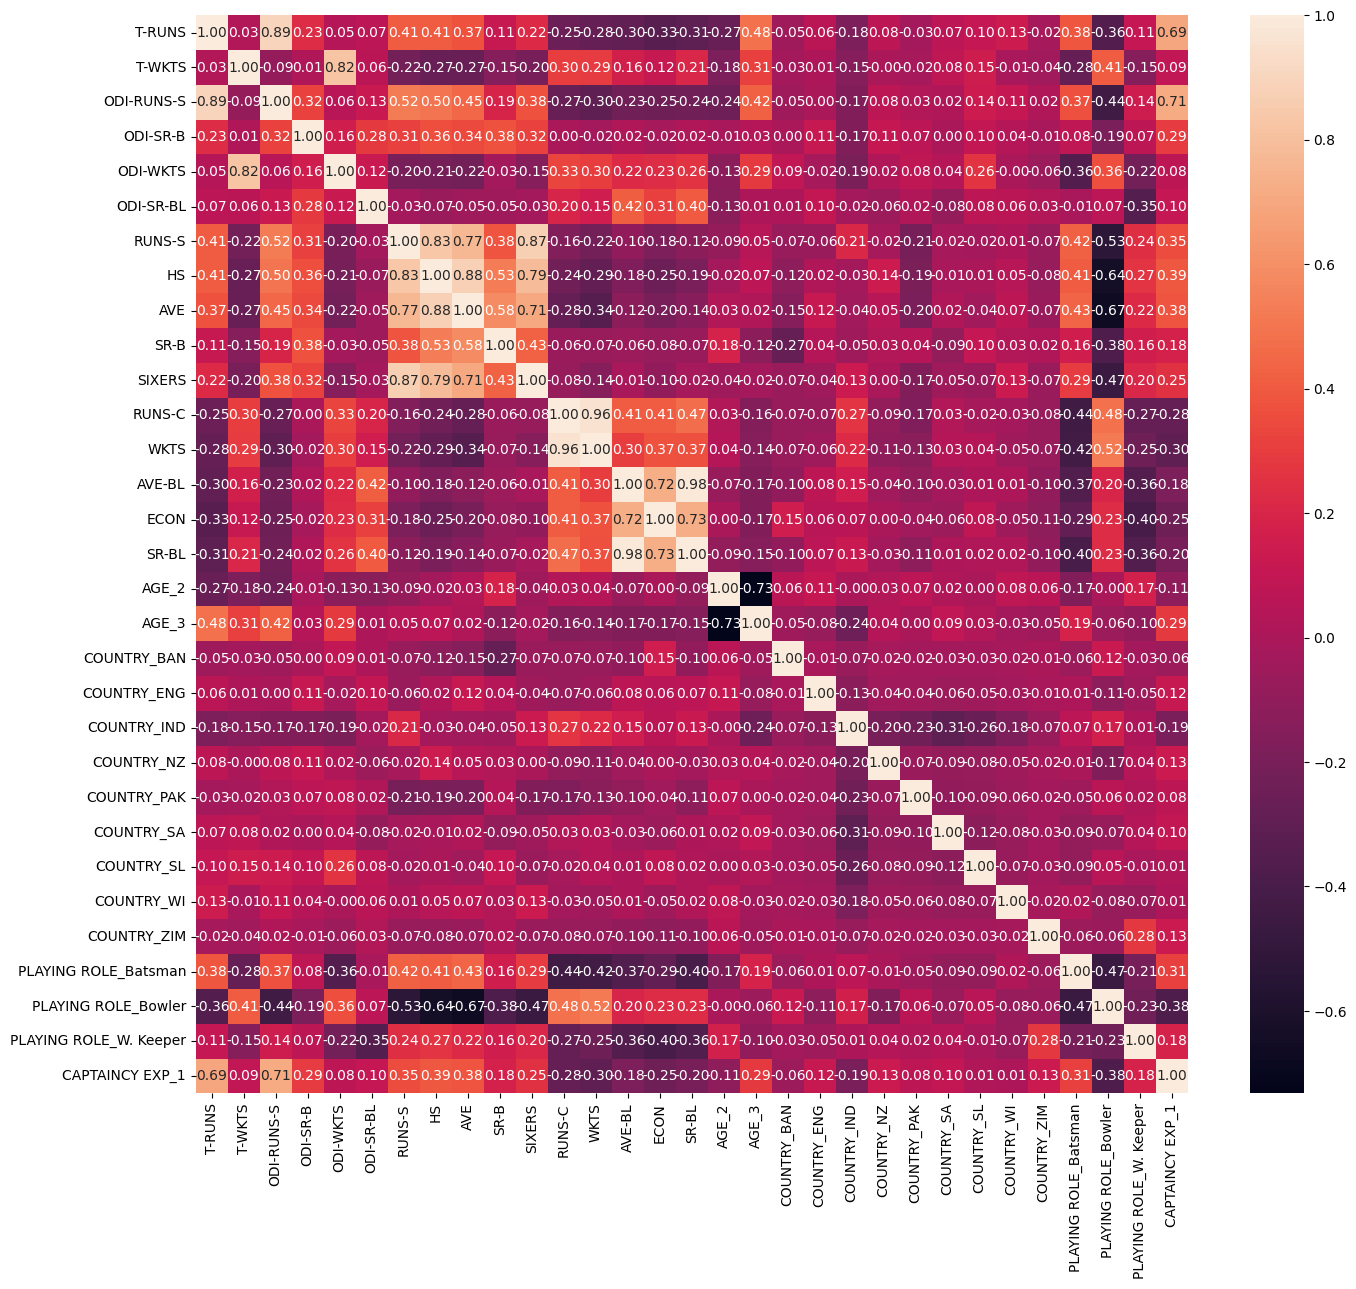

In [ ]:
fig,ax=plt.subplots(figsize=(16, 14))
sns.heatmap(data_en.corr(), annot=True,fmt='.2f')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
def get_vif(X):
  vif=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
  col=X.columns
  vif=pd.DataFrame({'col':col,'vif':vif})
  return vif
vif=get_vif(data_en)

In [ ]:
while True:
  if max(vif['vif'])<4:
    break
  new_features=list(vif[vif['vif']<max(vif['vif'])]['col'])
  new_data=data_en[new_features]
  vif=get_vif(new_data)
vif

,col,vif
0,T-WKTS,1.997945
1,ODI-SR-BL,3.200798
2,SIXERS,2.412588
3,WKTS,2.997161
4,ECON,3.578485
5,AGE_3,1.699075
6,COUNTRY_BAN,1.139904
7,COUNTRY_ENG,1.164778
8,COUNTRY_IND,3.397017
9,COUNTRY_NZ,1.228067


In [ ]:
new_features

['T-WKTS',
 'ODI-SR-BL',
 'SIXERS',
 'WKTS',
 'ECON',
 'AGE_3',
 'COUNTRY_BAN',
 'COUNTRY_ENG',
 'COUNTRY_IND',
 'COUNTRY_NZ',
 'COUNTRY_PAK',
 'COUNTRY_SA',
 'COUNTRY_SL',
 'COUNTRY_WI',
 'COUNTRY_ZIM',
 'PLAYING ROLE_Batsman',
 'PLAYING ROLE_Bowler',
 'PLAYING ROLE_W. Keeper',
 'CAPTAINCY EXP_1']

In [ ]:
X=data_en[new_features]
X=sm.add_constant(X)

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
model=sm.OLS(Y_train,X_train).fit()

In [ ]:
pred=model.predict(X_test)
r2_score(pred,Y_test)

0.19374105209057169

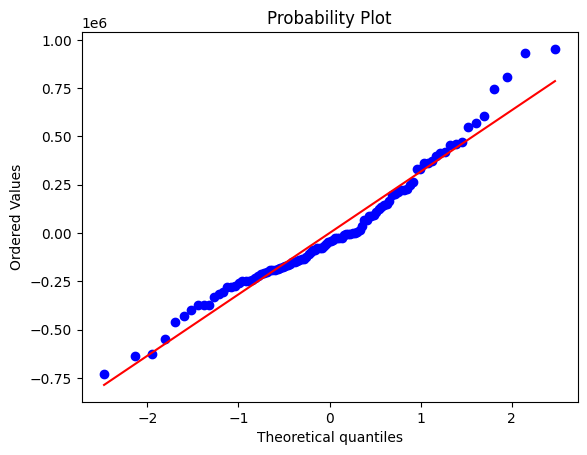

In [ ]:
import scipy.stats as se
se.probplot(model.resid,plot=plt)
plt.show()